<a href="https://colab.research.google.com/github/AmnaNoorr/NeuroQuantum-Edge-A-Hybrid-SNN-VQC-Architecture-for-Low-Power-Classification/blob/main/neuro_quantum_edge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model A: Pure Classical MLP**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

class ClassicalMLP(nn.Module):
    def __init__(self, num_inputs=784, num_hidden=64, num_latent=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(num_inputs, num_hidden),
            nn.ReLU(),
            nn.Linear(num_hidden, num_latent),
            nn.ReLU()
        )
        self.classifier = nn.Linear(num_latent, 2)

    def forward(self, x):
        latent_features = self.encoder(x)
        logits = self.classifier(latent_features)
        return logits

model_mlp = ClassicalMLP()
criterion = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(model_mlp.parameters(), lr=0.01)

In [24]:
loss_history_mlp = []
print("=== Training Model A: Pure Classical MLP ===")

for epoch in range(5):
    model_mlp.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1)
        optimizer_mlp.zero_grad()
        outputs = model_mlp(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_mlp.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history_mlp.append(avg_loss)
    print(f"Epoch [{epoch+1}/5] - Loss: {avg_loss:.4f}")

=== Training Model A: Pure Classical MLP ===
Epoch [1/5] - Loss: 0.0867
Epoch [2/5] - Loss: 0.0138
Epoch [3/5] - Loss: 0.0019
Epoch [4/5] - Loss: 0.0003
Epoch [5/5] - Loss: 0.0001


In [25]:
model_mlp.eval()
correct_mlp, total_mlp = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model_mlp(images)
        _, predicted = torch.max(outputs.data, 1)
        total_mlp += labels.size(0)
        correct_mlp += (predicted == labels).sum().item()

acc_mlp = 100 * correct_mlp / total_mlp
params_mlp = sum(p.numel() for p in model_mlp.parameters() if p.requires_grad)

print(f"MLP -> Start Loss: {loss_history_mlp[0]:.4f} | Final Loss: {loss_history_mlp[-1]:.4f}")
print(f"MLP -> Test Accuracy: {acc_mlp:.2f}% | Parameters: {params_mlp}\n")

MLP -> Start Loss: 0.0867 | Final Loss: 0.0001
MLP -> Test Accuracy: 100.00% | Parameters: 50510



# **Model B: Pure SNN Model (snnTorch Only)**

In [26]:
import snntorch as snn
from snntorch import surrogate

class PureSNN(nn.Module):
    def __init__(self, num_inputs=784, num_hidden=64, num_latent=4):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid()

        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=0.9, spike_grad=spike_grad)

        self.fc2 = nn.Linear(num_hidden, num_latent)
        self.lif2 = snn.Leaky(beta=0.9, spike_grad=spike_grad)

        self.classifier = nn.Linear(num_latent, 2)

    def forward(self, x, num_steps=10):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)

        spk_rate = torch.stack(spk2_rec, dim=0).mean(dim=0)
        logits = self.classifier(spk_rate)
        return logits

model_snn = PureSNN()
optimizer_snn = optim.Adam(model_snn.parameters(), lr=0.01)

In [27]:
loss_history_snn = []
print("=== Training Model B: Pure SNN ===")

for epoch in range(5):
    model_snn.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1)
        optimizer_snn.zero_grad()
        outputs = model_snn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_snn.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history_snn.append(avg_loss)
    print(f"Epoch [{epoch+1}/5] - Loss: {avg_loss:.4f}")


=== Training Model B: Pure SNN ===
Epoch [1/5] - Loss: 0.2568
Epoch [2/5] - Loss: 0.0607
Epoch [3/5] - Loss: 0.0317
Epoch [4/5] - Loss: 0.0215
Epoch [5/5] - Loss: 0.0166


In [28]:
model_snn.eval()
correct_snn, total_snn = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model_snn(images)
        _, predicted = torch.max(outputs.data, 1)
        total_snn += labels.size(0)
        correct_snn += (predicted == labels).sum().item()

acc_snn = 100 * correct_snn / total_snn
params_snn = sum(p.numel() for p in model_snn.parameters() if p.requires_grad)

print(f"SNN -> Start Loss: {loss_history_snn[0]:.4f} | Final Loss: {loss_history_snn[-1]:.4f}")
print(f"SNN -> Test Accuracy: {acc_snn:.2f}% | Parameters: {params_snn}\n")

SNN -> Start Loss: 0.2568 | Final Loss: 0.0166
SNN -> Test Accuracy: 100.00% | Parameters: 50510



# **Model C: Hybrid NeuroQuantum-Edge**

In [2]:
!pip install pennylane norse snntorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 133.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 115.9 MB/s eta 0:00:00
  Created wheel for norse: filename=norse-1.1.0-py3-none-any.whl size=15

In [3]:
import torch
import pennylane as qml
import snntorch as snn
import numpy as np
import matplotlib.pyplot as plt


In [4]:
print(torch.__version__)
print(qml.__version__)
print(snn.__version__)
print(np.__version__)

2.11.0+cu128
0.45.1
1.0.0
2.0.2


In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

define image transformation. convert to tensor and normalize

In [6]:
dataset = datasets.MNIST(root='./data', train = True, download = True, transform = transforms.ToTensor())
all_images = torch.stack([img for img, _ in dataset])
mean = all_images.mean().item()
std = all_images.std().item()
print("calculated mean:", mean)
print("calculated standard deviation:", std)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.49MB/s]


calculated mean: 0.13066047430038452
calculated standard deviation: 0.30810782313346863


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Normalize((mean,),(std,))
])

Training

In [8]:
train_dataset = datasets.MNIST(root='./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST(root = './data', train = False, download = True, transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

normalized images

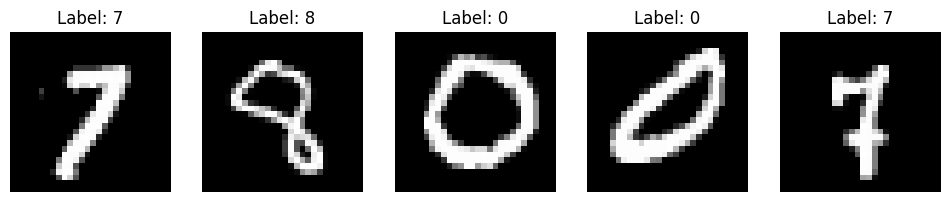

In [9]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
  img = images[i].squeeze()

  axes[i].imshow(img, cmap = 'gray')
  axes[i].set_title(f'Label: {labels[i].item()}')
  axes[i].axis('off')

plt.show()

SNN encoder

In [10]:
from snntorch import spikegen

In [11]:
images, labels = next(iter(train_loader))
num_steps = 20
#spike_data = spikegen.rate(images, num_steps = num_steps)
# Reduce the gain to 50% max probability to see the random flickering
spike_data = spikegen.rate(images * 0.5, num_steps=num_steps)

print(f"Original images shape: {images.shape}")
print(f"Encoded spikes shape: {spike_data.shape}")


Original images shape: torch.Size([64, 1, 28, 28])
Encoded spikes shape: torch.Size([20, 64, 1, 28, 28])


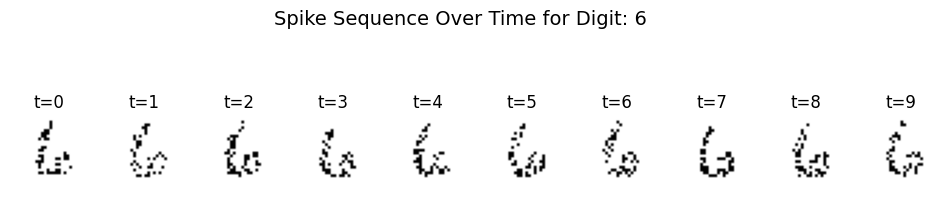

In [12]:
sample_index = 0
sample_label = labels[sample_index].item()
fig, axes = plt.subplots(1, 10, figsize=(12,3))
fig.suptitle(f"Spike Sequence Over Time for Digit: {sample_label}", fontsize=14)
for t in range(10):
  spike_frame = spike_data[t, sample_index].squeeze()
  axes[t].imshow(spike_frame, cmap='binary')
  axes[t].set_title(f"t={t}")
  axes[t].axis('off')
plt.show()

In [13]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
import pennylane as qml


QUANTUM LAYER CONFIGURATION (PennyLane)

In [14]:

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Angle Encoding: Map classical inputs onto qubit rotations
    for i in range(n_qubits):
        qml.RY(inputs[:, i], wires=i)

    # Entanglement & Parameterized Circuit
    for layer in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.RY(weights[layer, i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

    # Measurement: Expectation value on PauliZ
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Convert QNode into PyTorch Layer
weight_shapes = {"weights": (2, n_qubits)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)



HYBRID SNN-QUANTUM MODEL


In [15]:

class HybridNeuroQuantumNet(nn.Module):
    def __init__(self, num_inputs=784, num_hidden=64, num_latent=4):
        super().__init__()
        # SNN Encoder
        spike_grad = surrogate.fast_sigmoid()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=0.9, spike_grad=spike_grad)

        self.fc2 = nn.Linear(num_hidden, num_latent)
        self.lif2 = snn.Leaky(beta=0.9, spike_grad=spike_grad)

        # Quantum Classifier Head
        self.q_layer = quantum_layer
        self.out_fc = nn.Linear(num_latent, 2) # Binary output example

    def forward(self, x, num_steps=10):
        # Initialize membrane potentials
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []

        # Process temporal spikes over time steps
        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)

        # Rate coding: Average spike output over time
        spk_rate = torch.stack(spk2_rec, dim=0).mean(dim=0)

        # Quantum Circuit Execution
        q_out = self.q_layer(spk_rate)
        logits = self.out_fc(q_out)
        return logits



Instantiate Model

In [16]:
model = HybridNeuroQuantumNet()
dummy_input = torch.randn(16, 784) # Batch of 16 flattened images
output = model(dummy_input)
print("Hybrid Network Output Shape:", output.shape)

Hybrid Network Output Shape: torch.Size([16, 2])


PEnnylane broadcasting

In [17]:
@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Angle Encoding for batch inputs
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')

    # Entanglement & Parameterized Circuit
    for layer in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.RY(weights[layer, i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

Load Real MNIST Data (Filtered for 0 vs 1)

In [18]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# Download MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0,), (1,))])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Filter for Binary Classification (Digits 0 and 1 only)
idx = (train_dataset.targets == 0) | (train_dataset.targets == 1)
binary_dataset = Subset(train_dataset, torch.where(idx)[0][:1000]) # Take 1000 samples for fast run
train_loader = DataLoader(binary_dataset, batch_size=16, shuffle=True)

Training Loop & Track Loss

In [19]:
import torch.optim as optim

model = HybridNeuroQuantumNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_history = []
print("Starting Training Loop...")

for epoch in range(5): # 5 quick epochs
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1) # Flatten (16, 784)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/5] - Loss: {avg_loss:.4f}")

Starting Training Loop...
Epoch [1/5] - Loss: 0.2580
Epoch [2/5] - Loss: 0.0535
Epoch [3/5] - Loss: 0.0243
Epoch [4/5] - Loss: 0.0161
Epoch [5/5] - Loss: 0.0130


Generate Your First Result Plot

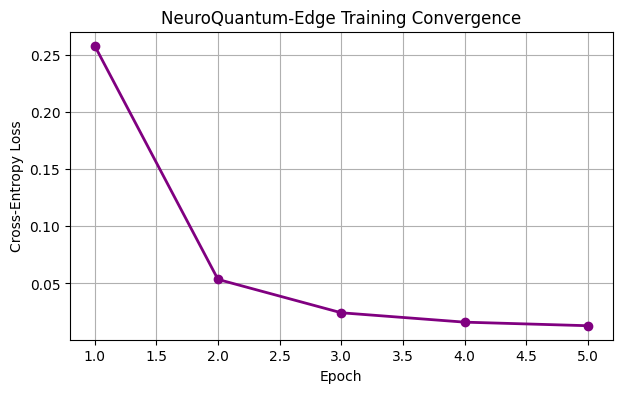

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, 6), loss_history, marker='o', color='purple', linewidth=2)
plt.title("NeuroQuantum-Edge Training Convergence")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.savefig("loss_curves.png")
plt.show()

In [21]:
# Compute Test Accuracy
correct = 0
total = 0

# Load test set (digits 0 and 1)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_idx = (test_dataset.targets == 0) | (test_dataset.targets == 1)
test_binary = Subset(test_dataset, torch.where(test_idx)[0][:200])
test_loader = DataLoader(test_binary, batch_size=16, shuffle=False)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy on Binary MNIST: {test_acc:.2f}%")

# Count Trainable Parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {trainable_params}")

Test Accuracy on Binary MNIST: 100.00%
Total Trainable Parameters: 50518


# **Comparative Convergence Plot**

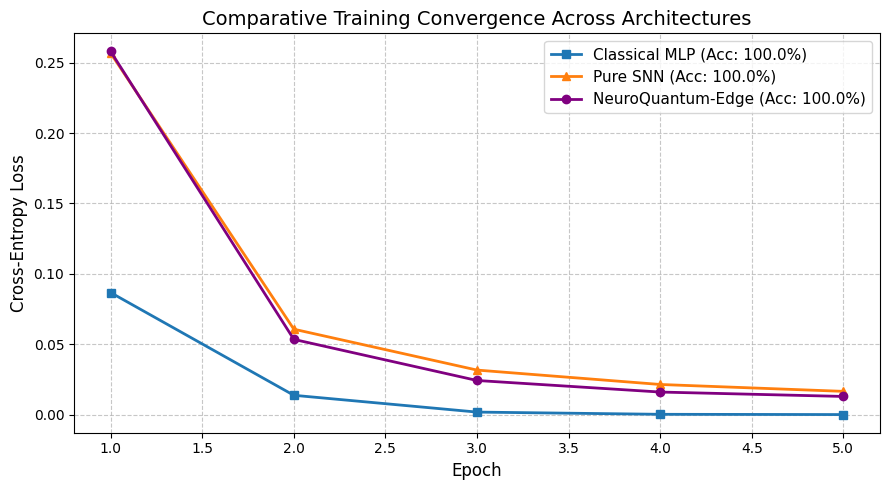

In [30]:
plt.figure(figsize=(9, 5))

# Plot All Three Histories
plt.plot(range(1, 6), loss_history_mlp, marker='s', linewidth=2, label=f"Classical MLP (Acc: {acc_mlp:.1f}%)")
plt.plot(range(1, 6), loss_history_snn, marker='^', linewidth=2, label=f"Pure SNN (Acc: {acc_snn:.1f}%)")
plt.plot(range(1, 6), loss_history, marker='o', linewidth=2, color='purple', label=f"NeuroQuantum-Edge (Acc: {test_acc:.1f}%)")

plt.title("Comparative Training Convergence Across Architectures", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

# Save combined figure
plt.savefig("benchmark_comparison.png", dpi=300)
plt.show()